# Combined time series figure

In [1]:
## import required packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:33693")
client

<Client: 'tcp://127.0.0.1:33693' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open ZARR datasets

In [6]:
# open FWC dataset
fwc_yrs_masked = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/FWC/FWC_masked_Beaufort.ZARR')
fwc_yrs_masked = fwc_yrs_masked.fwc_yrs_masked

In [7]:
sic_ds = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/SIC/SIC_masked_Beaufort.ZARR')

ice_fwc_over_2m = sic_ds.sic.where(fwc_yrs_masked>2).load()
ice_fwc_under_2m = sic_ds.sic.where(fwc_yrs_masked<2).load()

In [8]:
# open OHC zarr stores
ohc_mld_ds = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/OHC/OHC_MLD_Beaufort.ZARR')
ohc_mld_win_ds = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/OHC/OHC_MLD_winter_Beaufort.ZARR')

# select all cells with FWC above and below 2
ohc_fwc_over_2m =(ohc_mld_ds.ohc/1e6).where(fwc_yrs_masked>2).load() # convert J to MJ
ohc_fwc_under_2m = (ohc_mld_ds.ohc/1e6).where(fwc_yrs_masked<2).load() # convert J to MJ

ohc_win_fwc_over_2m = (ohc_mld_win_ds.ohc_winter/1e6).where(fwc_yrs_masked>2).load()
ohc_win_fwc_under_2m = (ohc_mld_win_ds.ohc_winter/1e6).where(fwc_yrs_masked<2).load()

In [9]:
mld_da = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/MLD/MLD_Beaufort_updated.ZARR')

# select all cells with FWC above and below 2
mld_fwc_over_2m = (mld_da.mld.where(fwc_yrs_masked>2)*-1).load()
mld_fwc_under_2m = (mld_da.mld.where(fwc_yrs_masked<2)*-1).load()

In [10]:
strat_da = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/STRAT/STRAT_Beaufort.ZARR')

# select all cells with FWC>2
strat_fwc_over_2m = strat_da.sigma.where(fwc_yrs_masked>2).load()
strat_fwc_under_2m = strat_da.sigma.where(fwc_yrs_masked<2).load()

### Make scatterplot of MLD, OHC, and FWC

In [11]:
fwc_subset = fwc_yrs_masked.isel(j=slice(0, None, 10),i=slice(0, None, 10))
ohc_subset = (ohc_mld_ds.ohc/1e6).isel(j=slice(0, None, 10),i=slice(0, None, 10)).where(~np.isnan(fwc_subset))
mld_subset = (mld_da.mld*-1).isel(j=slice(0, None, 10),i=slice(0, None, 10)).where(~np.isnan(fwc_subset))

In [12]:
fwc_subset = fwc_yrs_masked
ohc_subset = (ohc_mld_ds.ohc/1e6).where(~np.isnan(fwc_subset))
mld_subset = (mld_da.mld*-1).where(~np.isnan(fwc_subset))

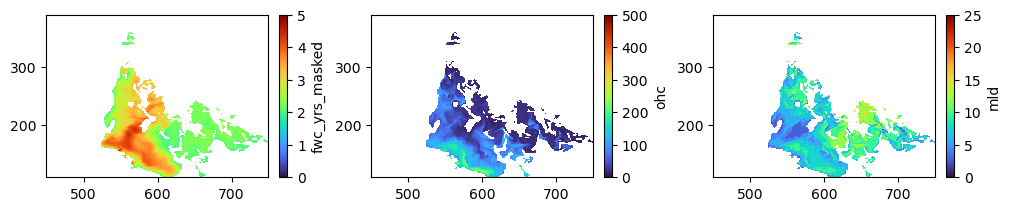

In [13]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[10,2],layout='constrained')
fwc_subset.isel(time=100).where(fwc_subset.isel(time=100)>2).plot(ax=ax1,cmap='turbo',vmin=0,vmax=5)
ohc_subset.isel(time=100).where(fwc_subset.isel(time=100)>2).plot(ax=ax2,cmap='turbo',vmin=0,vmax=500)
mld_subset.isel(time=100).where(fwc_subset.isel(time=100)>2).plot(ax=ax3,cmap='turbo',vmin=0,vmax=25);

for ax in (ax1,ax2,ax3):
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("");

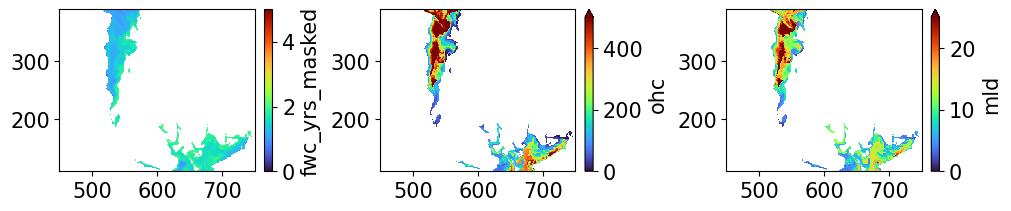

In [93]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[10,2],layout='constrained')
fwc_subset.isel(time=100).where(fwc_subset.isel(time=100)<2).plot(ax=ax1,cmap='turbo',vmin=0,vmax=5)
ohc_subset.isel(time=100).where(fwc_subset.isel(time=100)<2).plot(ax=ax2,cmap='turbo',vmin=0,vmax=500)
mld_subset.isel(time=100).where(fwc_subset.isel(time=100)<2).plot(ax=ax3,cmap='turbo',vmin=0,vmax=25);

for ax in (ax1,ax2,ax3):
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("");

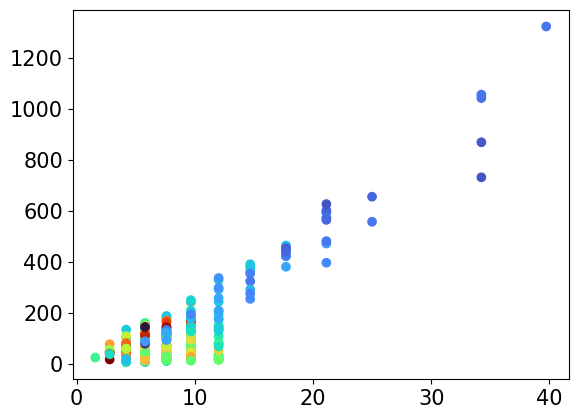

In [69]:
plt.scatter(mld_subset.isel(time=100),ohc_subset.isel(time=100),c=fwc_subset.isel(time=100),cmap='turbo')

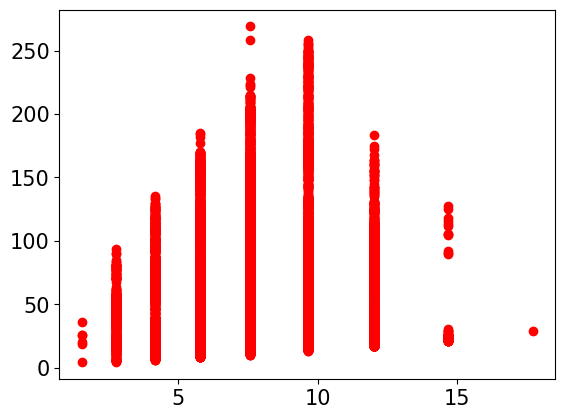

In [76]:
plt.scatter(mld_subset.isel(time=100).where(fwc_subset.isel(time=100)>2),ohc_subset.isel(time=100).where(fwc_subset.isel(time=100)>2),c='r')

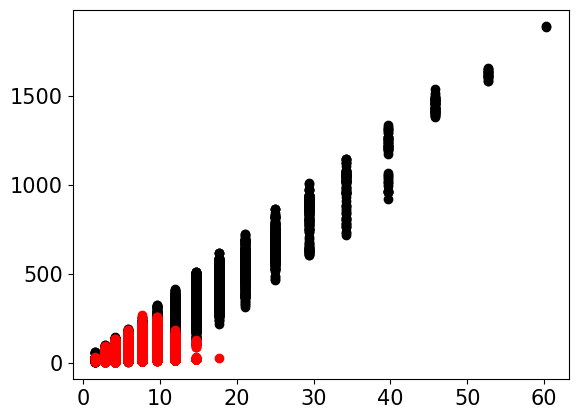

In [79]:
plt.scatter(mld_subset.isel(time=100).where(fwc_subset.isel(time=100)<2),ohc_subset.isel(time=100).where(fwc_subset.isel(time=100)<2),c='k')
plt.scatter(mld_subset.isel(time=100).where(fwc_subset.isel(time=100)>2),ohc_subset.isel(time=100).where(fwc_subset.isel(time=100)>2),c='r')

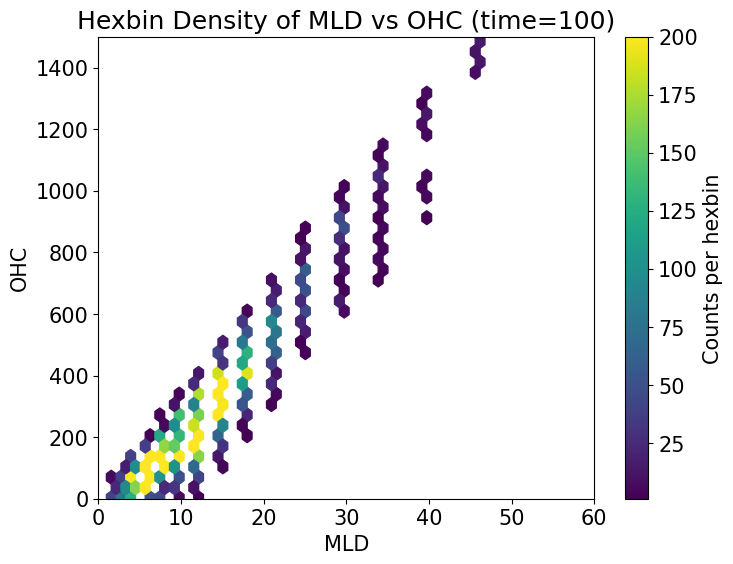

In [86]:
# Extract and flatten valid data (remove NaNs)
x = mld_subset.isel(time=100).where(fwc_subset.isel(time=100) < 2).values.flatten()
y = ohc_subset.isel(time=100).where(fwc_subset.isel(time=100) < 2).values.flatten()

# Remove NaN values (needed for hexbin)
mask = ~np.isnan(x) & ~np.isnan(y)
x_valid = x[mask]
y_valid = y[mask]

# Hexbin plot
plt.figure(figsize=(8, 6))
hb = plt.hexbin(x_valid, y_valid, gridsize=50, vmin=1, vmax=200, cmap='viridis', mincnt=1)
plt.colorbar(hb, label='Counts per hexbin')
plt.xlim(0,60)
plt.ylim(0,1500)
plt.xlabel("MLD")
plt.ylabel("OHC")
plt.title("Hexbin Density of MLD vs OHC (time=100)")
plt.show()

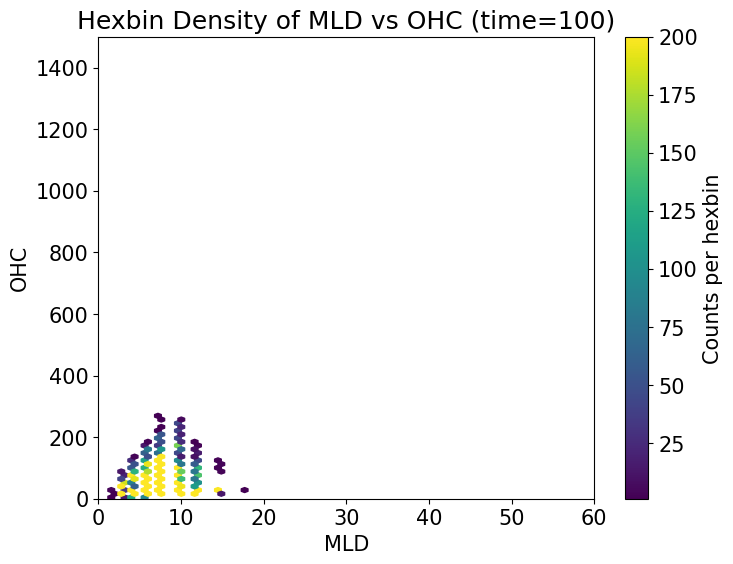

In [89]:
# Extract and flatten valid data (remove NaNs)
x = mld_subset.isel(time=100).where(fwc_subset.isel(time=100) > 2).values.flatten()
y = ohc_subset.isel(time=100).where(fwc_subset.isel(time=100) > 2).values.flatten()

# Remove NaN values (needed for hexbin)
mask = ~np.isnan(x) & ~np.isnan(y)
x_valid = x[mask]
y_valid = y[mask]

# Hexbin plot
plt.figure(figsize=(8, 6))
hb = plt.hexbin(x_valid, y_valid, gridsize=20, vmin=1, vmax=200, cmap='viridis', mincnt=1)
plt.colorbar(hb, label='Counts per hexbin')
plt.xlabel("MLD")
plt.ylabel("OHC")
plt.xlim(0,60)
plt.ylim(0,1500)
plt.title("Hexbin Density of MLD vs OHC (time=100)")
plt.show()

### Select representative profile inside and outside of plume

In [46]:
fwc_plu = fwc_yrs_masked.sel(j=190,i=555)
ohc_plu = (ohc_mld_ds.ohc/1e6).sel(j=190,i=555)
mld_plu = (mld_da.mld*-1).sel(j=190,i=555)

fwc_adj = fwc_yrs_masked.sel(j=320,i=555)
ohc_adj = (ohc_mld_ds.ohc/1e6).sel(j=320,i=555)
mld_adj = (mld_da.mld*-1).sel(j=320,i=555)

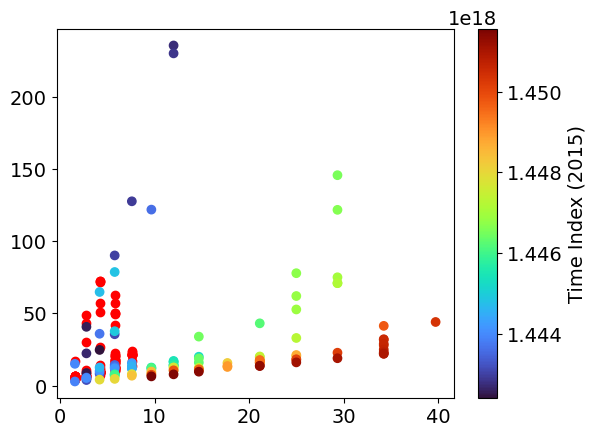

In [54]:
plt.scatter(mld_plu.sel(time='2015'), ohc_plu.sel(time='2015'), c='r')
sc2 = plt.scatter(mld_adj.sel(time='2015'), ohc_adj.sel(time='2015'), c=ohc_adj.sel(time='2015').time, cmap='turbo');

# Add colorbar for the time-colored points
cbar = plt.colorbar(sc2)
cbar.set_label('Time Index (2015)')

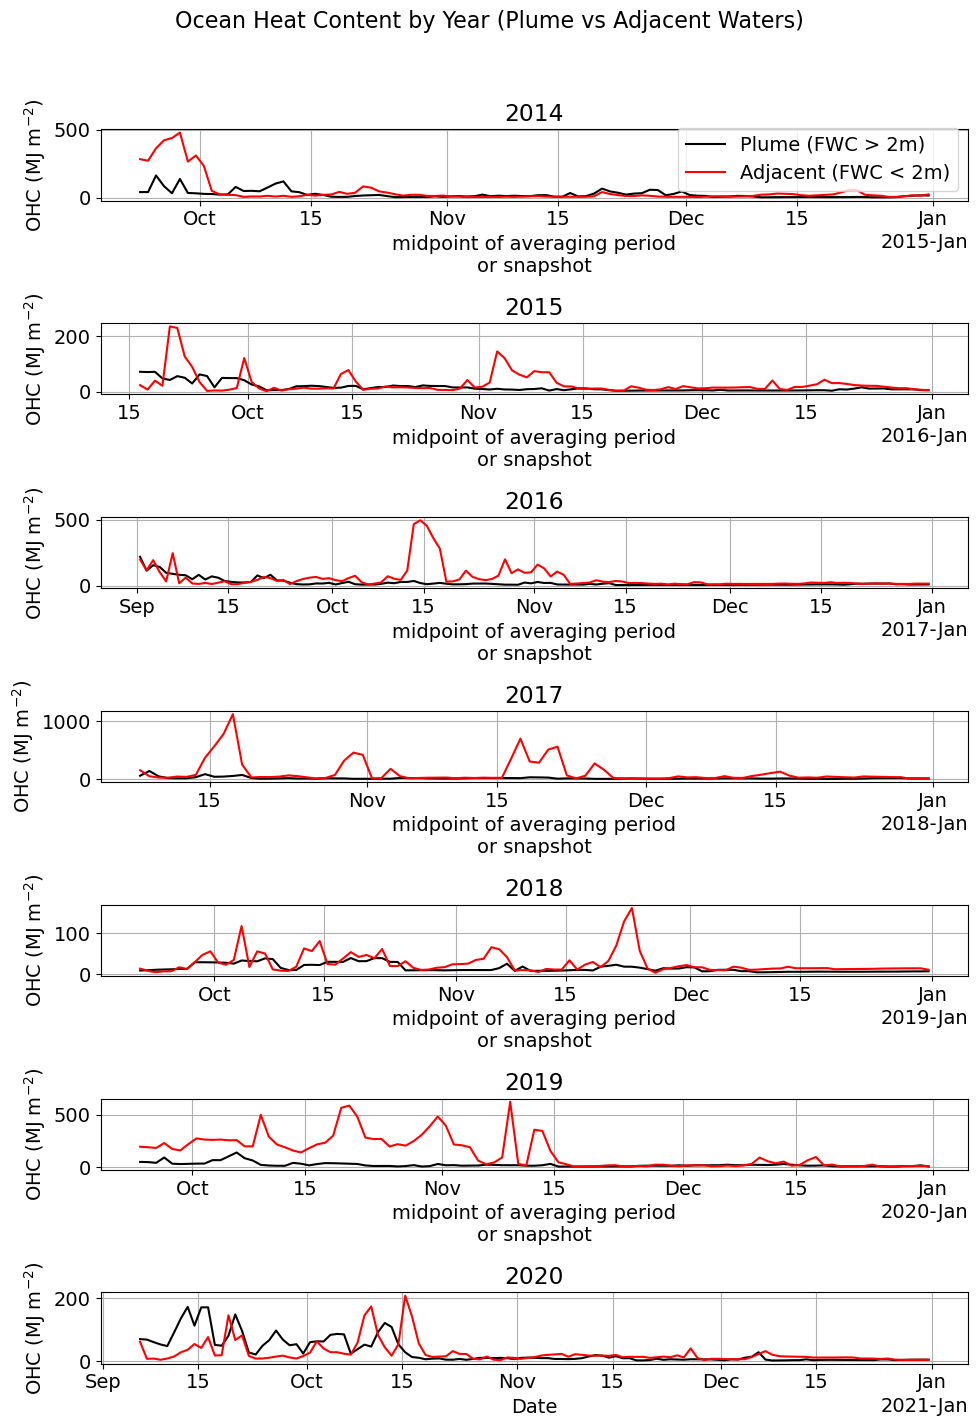

In [58]:
years = range(2014, 2021)
fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(10, 14))
fig.subplots_adjust(hspace=0.3)

for i, year in enumerate(years):
    ax = axes[i]

    # Select data for the current year
    ohc_plu_year = ohc_plu.sel(time=str(year))
    ohc_adj_year = ohc_adj.sel(time=str(year))

    # Plot both datasets on the same subplot
    ohc_plu_year.plot(ax=ax, label='Plume (FWC > 2m)', color='black')
    ohc_adj_year.plot(ax=ax, label='Adjacent (FWC < 2m)', color='red')

    ax.set_title(f'{year}')
    ax.set_ylabel('OHC (MJ m$^{-2}$)')
    ax.grid(True)

    # Add legend only to the first subplot
    if i == 0:
        ax.legend()

# Shared x-axis label
axes[-1].set_xlabel('Date')

plt.suptitle('Ocean Heat Content by Year (Plume vs Adjacent Waters)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

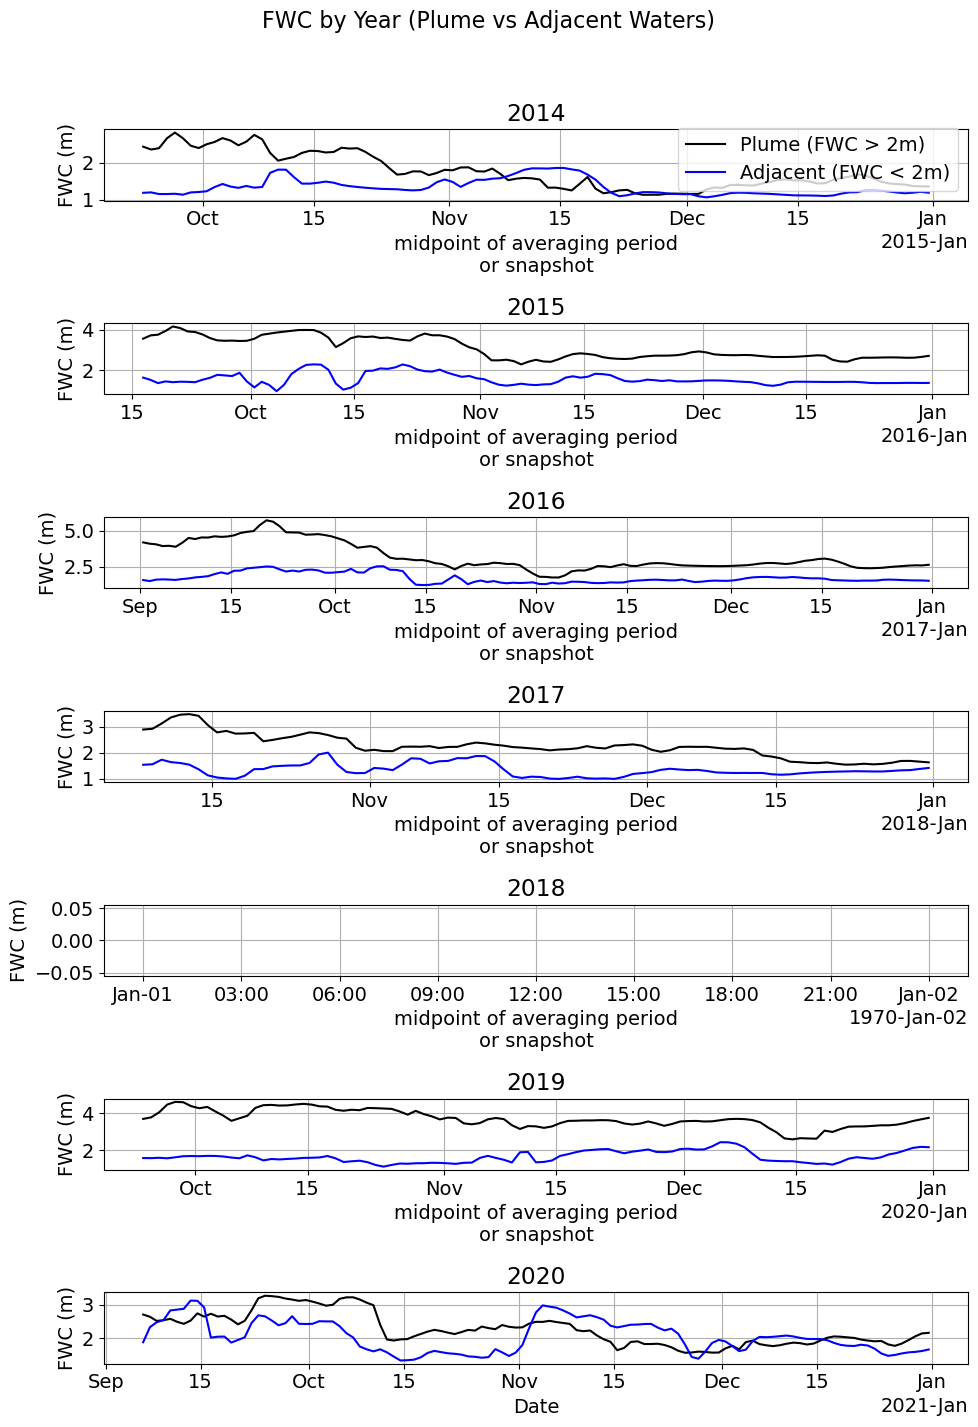

In [63]:
years = range(2014, 2021)
fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(10, 14))
fig.subplots_adjust(hspace=0.3)

for i, year in enumerate(years):
    ax = axes[i]

    # Select data for the current year
    fwc_plu_year = fwc_plu.sel(time=str(year))
    fwc_adj_year = fwc_adj.sel(time=str(year))

    # Plot both datasets on the same subplot
    fwc_plu_year.plot(ax=ax, label='Plume (FWC > 2m)', color='black')
    fwc_adj_year.plot(ax=ax, label='Adjacent (FWC < 2m)', color='blue')

    ax.set_title(f'{year}')
    ax.set_ylabel('FWC (m)')
    ax.grid(True)

    # Add legend only to the first subplot
    if i == 0:
        ax.legend()

# Shared x-axis label
axes[-1].set_xlabel('Date')

plt.suptitle('FWC by Year (Plume vs Adjacent Waters)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

(100.0, 400.0)

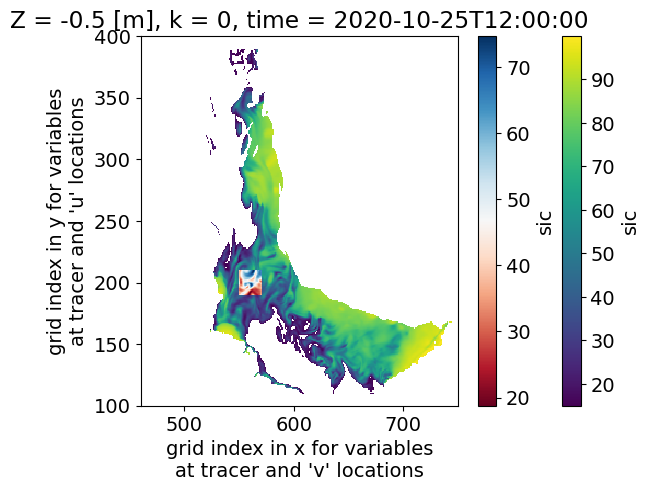

In [78]:
sic_over15 = sic_ds.sic.sel(time='2020-10-25').where(sic_ds.sic.sel(time='2020-10-25')>15)

fig, ax = plt.subplots(1,1)
sic_over15.plot(ax=ax);
sic_over15.sel(i=slice(550,570),j=slice(190,210)).plot(ax=ax,cmap='RdBu');

ax.set_xlim(460,750)
ax.set_ylim(100,400)

(100.0, 400.0)

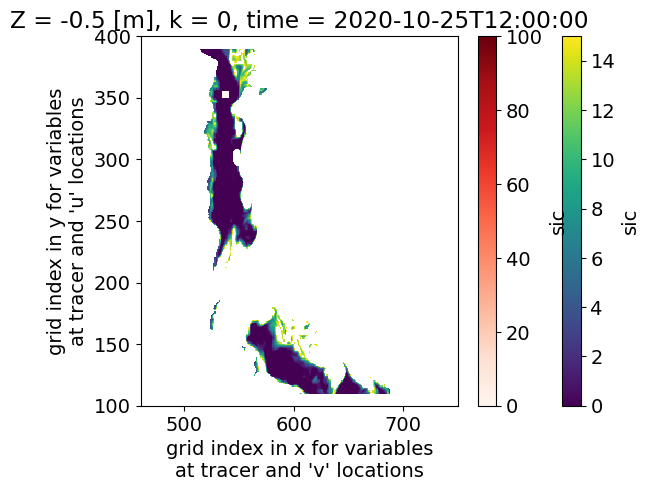

In [94]:
sic_under15 = sic_ds.sic.sel(time='2020-10-25').where(sic_ds.sic.sel(time='2020-10-25')<15)

fig, ax = plt.subplots(1,1)
sic_under15.plot(ax=ax);
sic_under15.sel(i=slice(535,540),j=slice(350,355)).plot(ax=ax,cmap='Reds',vmin=0,vmax=100);

ax.set_xlim(460,750)
ax.set_ylim(100,400)

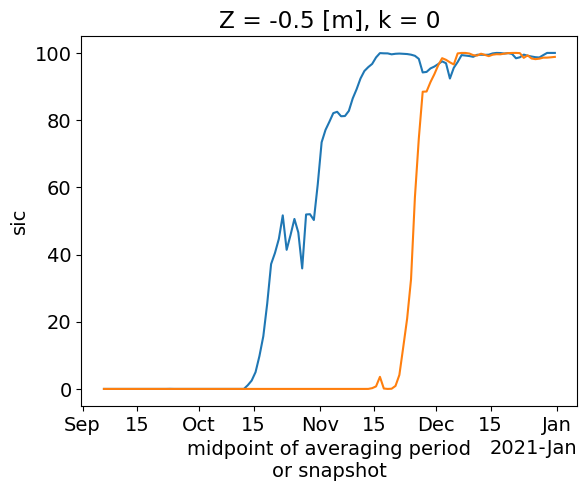

In [96]:
sic_ds.sic.sel(time='2020',i=slice(560,565),j=slice(195,200)).mean(dim=['i','j']).plot(label='plume');
sic_ds.sic.sel(time='2020',i=slice(535,540),j=slice(350,355)).mean(dim=['i','j']).plot(label='adjacent');

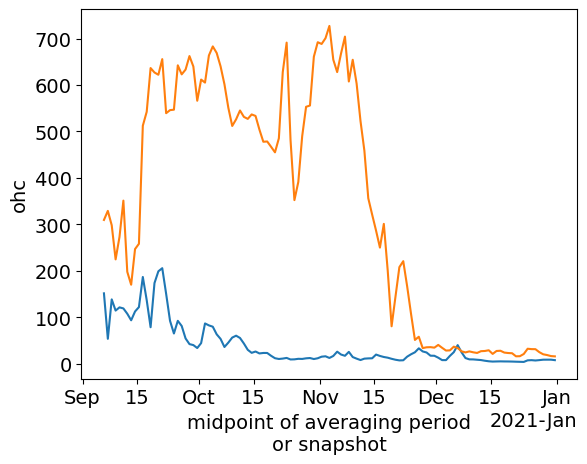

In [97]:
(ohc_mld_ds.ohc/1e6).sel(time='2020',i=slice(560,565),j=slice(195,200)).mean(dim=['i','j']).plot(label='plume');
(ohc_mld_ds.ohc/1e6).sel(time='2020',i=slice(535,540),j=slice(350,355)).mean(dim=['i','j']).plot(label='adjacent');

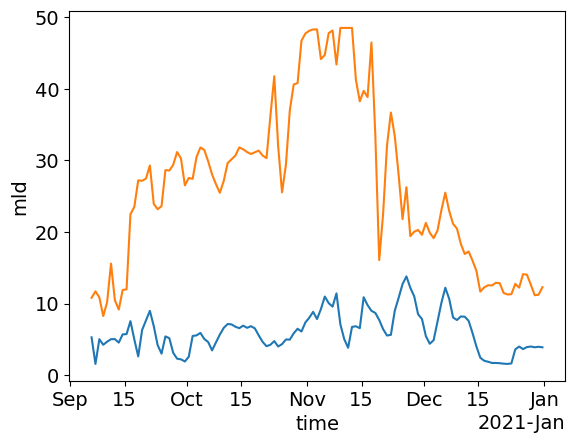

In [98]:
(mld_da.mld*-1).sel(time='2020',i=slice(560,565),j=slice(195,200)).mean(dim=['i','j']).plot(label='plume');
(mld_da.mld*-1).sel(time='2020',i=slice(535,540),j=slice(350,355)).mean(dim=['i','j']).plot(label='adjacent');

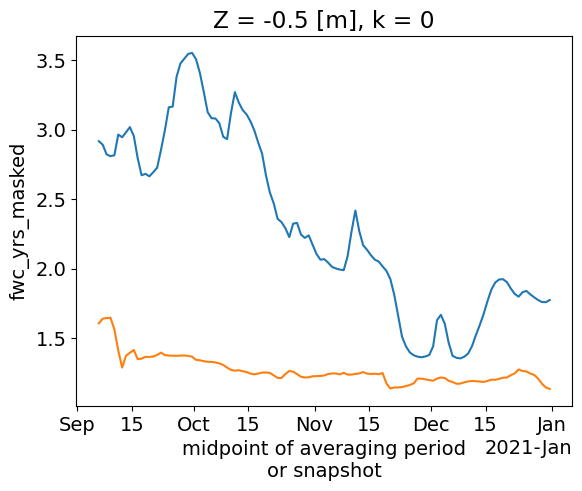

In [99]:
fwc_yrs_masked.sel(time='2020',i=slice(560,565),j=slice(195,200)).mean(dim=['i','j']).plot(label='plume');
fwc_yrs_masked.sel(time='2020',i=slice(535,540),j=slice(350,355)).mean(dim=['i','j']).plot(label='adjacent');

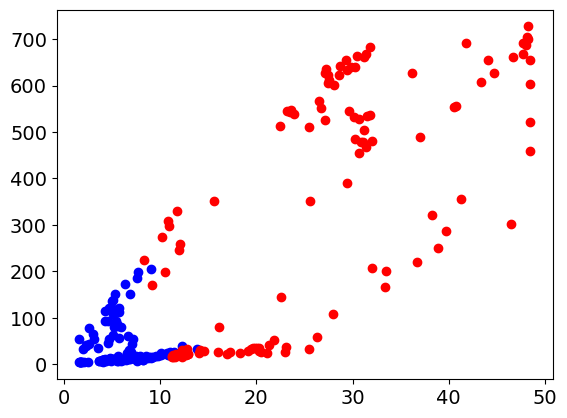

In [101]:
ohc_plu = (ohc_mld_ds.ohc/1e6).sel(time='2020',i=slice(560,565),j=slice(195,200)).mean(dim=['i','j'])
mld_plu = (mld_da.mld*-1).sel(time='2020',i=slice(560,565),j=slice(195,200)).mean(dim=['i','j'])

ohc_adj = (ohc_mld_ds.ohc/1e6).sel(time='2020',i=slice(535,540),j=slice(350,355)).mean(dim=['i','j'])
mld_adj = (mld_da.mld*-1).sel(time='2020',i=slice(535,540),j=slice(350,355)).mean(dim=['i','j'])

plt.scatter(mld_plu, ohc_plu, c='blue')
plt.scatter(mld_adj, ohc_adj, c='red')

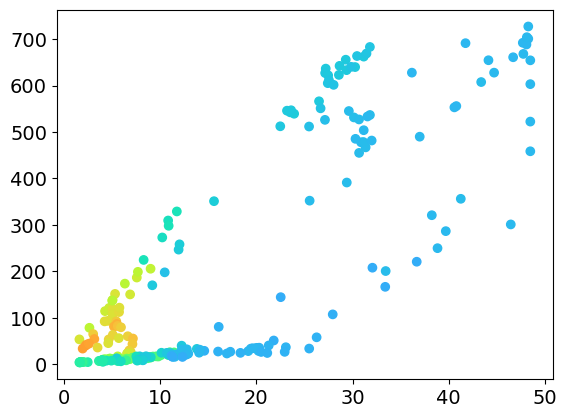

In [102]:
ohc_plu = (ohc_mld_ds.ohc/1e6).sel(time='2020',i=slice(560,565),j=slice(195,200)).mean(dim=['i','j'])
mld_plu = (mld_da.mld*-1).sel(time='2020',i=slice(560,565),j=slice(195,200)).mean(dim=['i','j'])
fwc_plu = fwc_yrs_masked.sel(time='2020',i=slice(560,565),j=slice(195,200)).mean(dim=['i','j'])

ohc_adj = (ohc_mld_ds.ohc/1e6).sel(time='2020',i=slice(535,540),j=slice(350,355)).mean(dim=['i','j'])
mld_adj = (mld_da.mld*-1).sel(time='2020',i=slice(535,540),j=slice(350,355)).mean(dim=['i','j'])
fwc_adj = fwc_yrs_masked.sel(time='2020',i=slice(535,540),j=slice(350,355)).mean(dim=['i','j'])

plt.scatter(mld_plu, ohc_plu, c=fwc_plu, cmap='turbo', vmin=0, vmax=5)
plt.scatter(mld_adj, ohc_adj, c=fwc_adj, cmap='turbo', vmin=0, vmax=5)

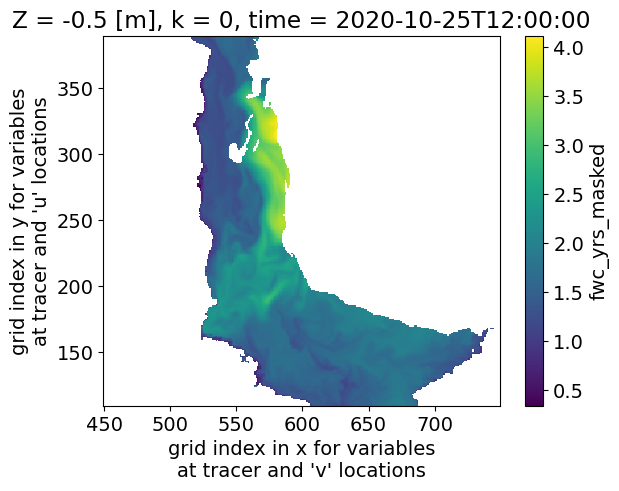

In [71]:
fwc_yrs_masked.sel(time='2020-10-25').plot();

### Add vertical lines for where SIC>=15% and remain above it for at least 5 days


In [11]:
# first day when sea ice concentration (SIC) reaches or exceeds 15% and stays above that threshold for at least 5 consecutive days
years = np.arange(2014, 2021)

ice_fwc_over_2m_dates = []
ice_fwc_under_2m_dates = []

for year in years:
    # Compute mean SIC over space
    ice_over_mean = ice_fwc_over_2m.sel(time=str(year)).mean(dim=['i', 'j'], skipna=True).compute()
    ice_under_mean = ice_fwc_under_2m.sel(time=str(year)).mean(dim=['i', 'j'], skipna=True).compute()
    
    # Convert to boolean where SIC >= 15
    ice_over_bool = ice_over_mean >= 15
    ice_under_bool = ice_under_mean >= 15

    # Find the first day where there are 5+ consecutive True values
    def find_persistent_threshold(bool_array, time_array, window=5):
        bool_np = bool_array.values
        for i in range(len(bool_np) - window + 1):
            if np.all(bool_np[i:i+window]):
                return time_array[i].values
        return np.datetime64('NaT')  # If no valid period found

    over_time = ice_over_mean['time']
    under_time = ice_under_mean['time']

    ice_over_date = find_persistent_threshold(ice_over_bool, over_time)
    ice_under_date = find_persistent_threshold(ice_under_bool, under_time)

    ice_fwc_over_2m_dates.append(ice_over_date)
    ice_fwc_under_2m_dates.append(ice_under_date)

## Combined plot

In [12]:
def compute_aligned_stats(data_over, data_under, year):
    # Select data for a specific year
    data_over_yr = data_over.sel(time=str(year))
    data_under_yr = data_under.sel(time=str(year))

    # Find the first valid sea ice day (non-NaN mean)
    mean_over = data_over_yr.mean(dim=['i', 'j'])
    first_valid_index = mean_over.notnull().argmax().compute().item()

    # Slice data from that index onward
    mean_over = mean_over.isel(time=slice(first_valid_index, None))
    mean_under = data_under_yr.mean(dim=['i', 'j']).isel(time=slice(first_valid_index, None))

    std_over = data_over_yr.isel(time=slice(first_valid_index, None)).std(dim=['i', 'j'])
    std_under = data_under_yr.isel(time=slice(first_valid_index, None)).std(dim=['i', 'j'])

    x = np.arange(len(mean_over))  # relative day index

    return x, mean_over, std_over, mean_under, std_under

def plot_variable_row(fig, axes_row, year, variable_pairs, titles, ice_fwc_over_2m_dates, ice_fwc_under_2m_dates, row_idx):
    for j, ((data_over, data_under), title) in enumerate(zip(variable_pairs, titles)):
        ax = axes_row[j]
        x, mean_over, std_over, mean_under, std_under = compute_aligned_stats(data_over, data_under, year)

        ax.plot(x, mean_over, color='tab:blue', label='FWC > 2m')
        ax.fill_between(x, mean_over - std_over, mean_over + std_over, color='tab:blue', alpha=0.3)

        ax.plot(x, mean_under, color='k', label='FWC < 2m')
        ax.fill_between(x, mean_under - std_under, mean_under + std_under, color='gray', alpha=0.2)

        ax.set_xlim([0, 60])
        ax.grid(True)

        if j == 0:
            ax.set_ylabel(f"{year}", rotation=0, labelpad=30, fontsize=16)
            ax.axvline(x=np.where(mean_over.time.values == ice_fwc_over_2m_dates[row_idx])[0][0],color='tab:blue',linestyle='dashed')
            ax.axvline(x=np.where(mean_under.time.values == ice_fwc_under_2m_dates[row_idx])[0][0],color='k',linestyle='dashed')
            
        if year == 2014:
            ax.set_title(title, fontsize=16)

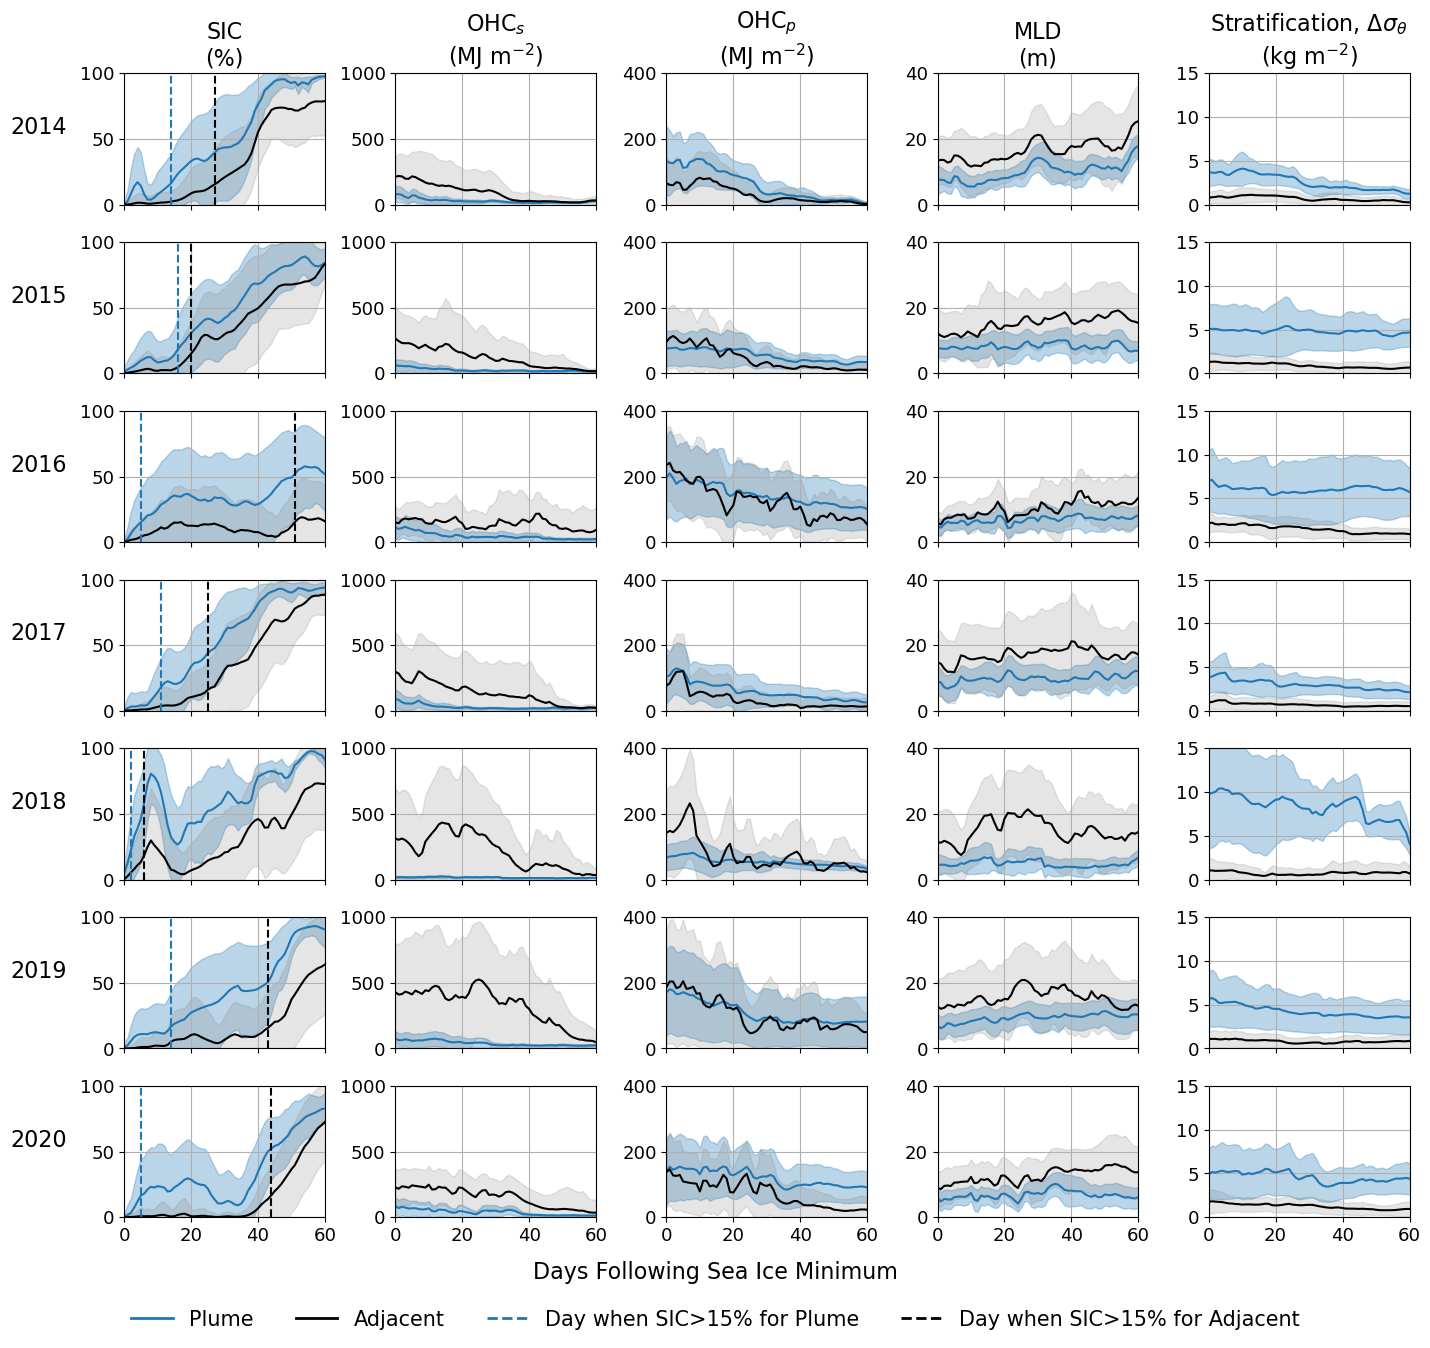

In [13]:
years = np.arange(2014, 2021)
nrows, ncols = len(years), 5

# Your variable list: each is a tuple (over_2m, under_2m)
variable_pairs = [
    (ice_fwc_over_2m, ice_fwc_under_2m),
    (ohc_fwc_over_2m, ohc_fwc_under_2m),
    (ohc_win_fwc_over_2m, ohc_win_fwc_under_2m),
    (mld_fwc_over_2m, mld_fwc_under_2m),
    (strat_fwc_over_2m, strat_fwc_under_2m)
]

variable_titles = [
    'SIC\n(%)',
    'OHC$_s$\n(MJ m$^{-2}$)',
    'OHC$_p$\n(MJ m$^{-2}$)',
    'MLD\n(m)',
    'Stratification, $\Delta \\sigma_{\\theta}$\n(kg m$^{-2}$)'
]

# --- Create figure ---
plt.rcParams['font.size'] = 13
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14.5, 14), sharex=True, sharey='col')

# Plot each row/year
for i, year in enumerate(years):
    plot_variable_row(fig, axes[i], year, variable_pairs, variable_titles, ice_fwc_over_2m_dates, ice_fwc_under_2m_dates, row_idx=i)

# Custom legend in one corner subplot
custom_lines = [Line2D([0], [0], color='tab:blue', lw=2), \
                Line2D([0], [0], color='k', lw=2), \
                Line2D([0], [0], color='tab:blue', lw=2, linestyle='dashed'), \
                Line2D([0], [0], color='k', lw=2, linestyle='dashed')]
# axes[-1, -1].legend(custom_lines, ['FWC > 2m', 'FWC < 2m'], loc='upper right', fontsize=10)

fig.legend(
    custom_lines,
    # ['FWC > 2m', 'FWC < 2m', 'Day when SIC>15% for FWC > 2m', 'Day when SIC>15% for FWC < 2m'],
    ['Plume', 'Adjacent', 'Day when SIC>15% for Plume', 'Day when SIC>15% for Adjacent'],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.01),  # adjust Y as needed
    ncol=4,
    fontsize=15,
    frameon=False  # optional: no box around legend
)

# Set consistent y-axis limits per column
axes[0,0].set_ylim(0,100)
axes[0,1].set_ylim(0,1000)
axes[0,2].set_ylim(0,400)
axes[0,3].set_ylim(0,40)
axes[0,4].set_ylim(0,15)

# --- Add shared x-label ---
fig.text(0.5, 0.04, 'Days Following Sea Ice Minimum', ha='center', fontsize=16)

# for col in range(ncols-1):
#     for row in range(nrows):
#         ax = axes[row, col]
#         labels = ax.get_yticklabels()
        # for i, label in enumerate(labels):
        #     if i % 2 == 1:  # hide every other label (e.g., odd-indexed ones)
        #         label.set_visible(False)

# Tight layout with room for x-label
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.subplots_adjust(wspace=0.35) 
plt.show()

# fig.savefig('/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/fwc_group_time_series.png', \
#             dpi=300, bbox_inches='tight')
fig.savefig('/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/figS3.png', \
            dpi=300, bbox_inches='tight')

## Mean of all time series

In [14]:
# Store the normalized DataArrays
normalized_sic_list = []

# Loop over each year
for year, da_year in ice_fwc_under_2m.groupby('time.year'):
    
    # Compute days since start of that year (or since sea ice min)
    days_since_min = ((da_year.time - da_year.time.values[0]) / np.timedelta64(1, 'D')).astype(int)
    
    # Replace the time coordinate with days_since_min
    da_year = da_year.assign_coords(time=days_since_min.data)
    da_year = da_year.rename({'time': 'days_since_min'})
    
    # Add 'year' as a new dimension
    da_year = da_year.expand_dims(dim={'year': [year]})
    
    normalized_sic_list.append(da_year)

# Concatenate into a single DataArray with dims: (year, days_since_min, j, i)
sic_normalized = xr.concat(normalized_sic_list, dim='year')

# Now take spatial mean (only once!)
sic_mean_under = sic_normalized.mean(dim=['j', 'i', 'year'])  # dims: (year, days_since_min)
sic_std_under = sic_normalized.std(dim=['j', 'i', 'year'])  # dims: (year, days_since_min)

In [15]:
sic_normalized.count().sum().item()

10268851

In [16]:
# Store the normalized DataArrays
normalized_sic_list = []

# Loop over each year
for year, da_year in ice_fwc_over_2m.groupby('time.year'):
    
    # Compute days since start of that year (or since sea ice min)
    days_since_min = ((da_year.time - da_year.time.values[0]) / np.timedelta64(1, 'D')).astype(int)
    
    # Replace the time coordinate with days_since_min
    da_year = da_year.assign_coords(time=days_since_min.data)
    da_year = da_year.rename({'time': 'days_since_min'})
    
    # Add 'year' as a new dimension
    da_year = da_year.expand_dims(dim={'year': [year]})
    
    normalized_sic_list.append(da_year)

# Concatenate into a single DataArray with dims: (year, days_since_min, j, i)
sic_normalized = xr.concat(normalized_sic_list, dim='year')

# Now take spatial mean (only once!)
sic_mean_over = sic_normalized.mean(dim=['j', 'i', 'year'])  # dims: (year, days_since_min)
sic_std_over = sic_normalized.std(dim=['j', 'i', 'year'])  # dims: (year, days_since_min)

In [17]:
sic_normalized.count().sum().item()

5950955

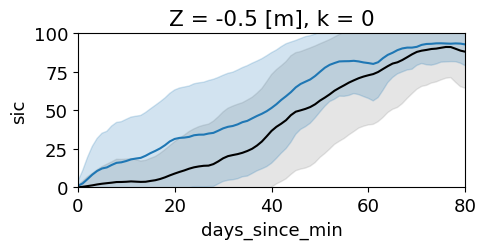

In [18]:
fig, ax = plt.subplots(1,1,figsize=[5,2])

sic_mean_under.plot(ax=ax,color='k')
ax.fill_between(sic_mean_under.days_since_min, sic_mean_under - sic_std_under, sic_mean_under + sic_std_under, \
                color='gray', alpha=0.2, label='FWC < 2')

sic_mean_over.plot(ax=ax,color='tab:blue')
ax.fill_between(sic_mean_over.days_since_min, sic_mean_over - sic_std_over, sic_mean_over + sic_std_over, \
                color='tab:blue', alpha=0.2, label='FWC < 2')

ax.set_xlim(0,80)
ax.set_ylim(0,100);

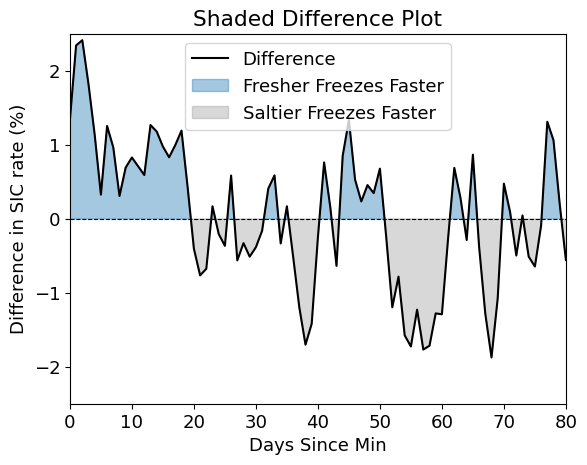

In [19]:
# Compute the difference
diff = sic_mean_over.diff(dim='days_since_min',label="lower") - sic_mean_under.diff(dim='days_since_min',label="lower")

# Extract the x and y data
x = diff['days_since_min']
y = diff.values

# Plot the line
plt.plot(x, y, color='black', label='Difference')

# Shade above zero (blue)
plt.fill_between(x, y, 0, where=(y > 0), interpolate=True, color='tab:blue', alpha=0.4, label='Fresher Freezes Faster')

# Shade below zero (gray)
plt.fill_between(x, y, 0, where=(y < 0), interpolate=True, color='gray', alpha=0.3, label='Saltier Freezes Faster')

plt.xlim(0, 80)
plt.ylim(-2.5,2.5)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend()
plt.xlabel("Days Since Min")
plt.ylabel("Difference in SIC rate (%)")
plt.title("Shaded Difference Plot")
plt.show()

In [13]:
def normalize_and_avg_da(da, group_dim='time.year', min_day_dim='days_since_min',
                         spatial_dims=['j', 'i'], time_dim='time'):
    """
    Normalize a DataArray by computing days since the start of each year (or group),
    then compute the mean and std over space and group (e.g., year).

    Parameters:
    -----------
    da : xarray.DataArray
        The input DataArray with dimensions including time and spatial dims.
    group_dim : str
        The time-based group dimension for separation (default: 'time.year').
    min_day_dim : str
        The name for the new time coordinate (default: 'days_since_min').
    spatial_dims : list of str
        The names of spatial dimensions to average over (default: ['j', 'i']).
    time_dim : str
        The name of the time dimension (default: 'time').

    Returns:
    --------
    da_mean : xarray.DataArray
        Mean over space and group. Dims: (days_since_min,)
    da_std : xarray.DataArray
        Std deviation over space and group. Dims: (days_since_min,)
    """
    normalized_list = []

    for group_val, da_group in da.groupby(group_dim):
        days_since = ((da_group[time_dim] - da_group[time_dim].values[0]) /
                      np.timedelta64(1, 'D')).astype(int)
        da_group = da_group.assign_coords({time_dim: days_since.data})
        da_group = da_group.rename({time_dim: min_day_dim})
        da_group = da_group.expand_dims(dim={group_dim.split('.')[-1]: [group_val]})
        normalized_list.append(da_group)

    da_normalized = xr.concat(normalized_list, dim=group_dim.split('.')[-1])
    da_mean = da_normalized.mean(dim=spatial_dims + [group_dim.split('.')[-1]])
    da_std = da_normalized.std(dim=spatial_dims + [group_dim.split('.')[-1]])

    return da_mean, da_std

In [14]:
# compute normalized datasets and mean/std

# SIC
sic_mean_over, sic_std_over = normalize_and_avg_da(ice_fwc_over_2m)
sic_mean_under, sic_std_under = normalize_and_avg_da(ice_fwc_under_2m)

# OHC in surface ML
ohc_mean_over, ohc_std_over = normalize_and_avg_da(ohc_fwc_over_2m)
ohc_mean_under, ohc_std_under = normalize_and_avg_da(ohc_fwc_under_2m)

# OHC above winter ML
ohc_win_mean_over, ohc_win_std_over = normalize_and_avg_da(ohc_win_fwc_over_2m)
ohc_win_mean_under, ohc_win_std_under = normalize_and_avg_da(ohc_win_fwc_under_2m)

# MLD
mld_mean_over, mld_std_over = normalize_and_avg_da(mld_fwc_over_2m)
mld_mean_under, mld_std_under = normalize_and_avg_da(mld_fwc_under_2m)

# stratification
strat_mean_over, strat_std_over = normalize_and_avg_da(strat_fwc_over_2m)
strat_mean_under, strat_std_under = normalize_and_avg_da(strat_fwc_under_2m)

In [15]:
def plot_var_mean(ax, var_mean_under, var_std_under, var_mean_over, var_std_over, upper_xy_limits=[80 ,100], title='Mean SIC', ylabel=''):
    # Plot the variable mean + std shading for over and under FWC=2
    var_mean_over.plot(ax=ax, color='tab:blue')
    ax.fill_between(
        var_mean_over.days_since_min,
        var_mean_over - var_std_over,
        var_mean_over + var_std_over,
        color='tab:blue', alpha=0.2)

    var_mean_under.plot(ax=ax, color='k')
    ax.fill_between(
        var_mean_under.days_since_min,
        var_mean_under - var_std_under,
        var_mean_under + var_std_under,
        color='gray', alpha=0.2)

    ax.set_xlim(0, upper_xy_limits[0])
    ax.set_ylim(0, upper_xy_limits[1])
    ax.set_xlabel("")
    ax.set_title(title)
    ax.set_ylabel(ylabel)

In [16]:
def plot_sic_diff_shading(ax, sic_mean_over, sic_mean_under):
    diff = sic_mean_over.diff(dim='days_since_min',label="lower") - sic_mean_under.diff(dim='days_since_min',label="lower")
    x = diff['days_since_min']
    y = diff.values

    ax.plot(x, y, color='black',linewidth=0.8)
    ax.fill_between(x, y, 0, where=(y > 0), interpolate=True, color='tab:blue', alpha=0.4, label='Fresher Freezes Faster')
    ax.fill_between(x, y, 0, where=(y < 0), interpolate=True, color='gray', alpha=0.3, label='Saltier Freezes Faster')

    ax.set_xlim(0, 80)
    ax.set_ylim(-2, 2.6)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.legend(loc='upper right',fontsize=12)
    ax.set_title("SIC Rate Difference")
    ax.set_xlabel("")
    ax.set_ylabel("Δ SIC Rate (%/day)")

In [17]:
def plot_sic_mean(ax, sic_mean_under, sic_std_under, sic_mean_over, sic_std_over, upper_xy_limits=[80, 100], title='Mean SIC'):
    # Plot the SIC mean + std shading for over and under
    sic_mean_over.plot(ax=ax, color='tab:blue', label='FWC > 2 m')
    ax.fill_between(
        sic_mean_over.days_since_min,
        sic_mean_over - sic_std_over,
        sic_mean_over + sic_std_over,
        color='tab:blue', alpha=0.2)

    sic_mean_under.plot(ax=ax, color='k', label='FWC < 2 m')
    ax.fill_between(
        sic_mean_under.days_since_min,
        sic_mean_under - sic_std_under,
        sic_mean_under + sic_std_under,
        color='gray', alpha=0.2)

    # Function to find threshold crossings (>= 5 consecutive days > 15%)
    def find_threshold_crossings(sic_mean, threshold=15, min_duration=5):
        above = sic_mean > threshold
        above = above.astype(int).values
        crossings = []

        count = 0
        for i in range(len(above)):
            if above[i]:
                count += 1
                if count == min_duration:
                    crossings.append(sic_mean.days_since_min[i - min_duration + 1].item())
            else:
                count = 0
        return crossings

    # Add vertical lines for each group
    over_thresh = find_threshold_crossings(sic_mean_over)
    ax.axvline(over_thresh, color='tab:blue', linestyle='--', linewidth=1.6)

    under_thresh = find_threshold_crossings(sic_mean_under)
    ax.axvline(under_thresh, color='k', linestyle='--', linewidth=1.6)

    ax.set_xlim(0, upper_xy_limits[0])
    ax.set_ylim(0, upper_xy_limits[1])
    ax.legend(fontsize=12)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Sea Ice Conc (%)")

    return under_thresh, over_thresh

In [25]:
under_thresh, over_thresh = plot_sic_mean(ax, sic_mean_under, sic_std_under, sic_mean_over, sic_std_over, upper_xy_limits=[80, 100], title='Mean SIC')

In [26]:
under_thresh[0] - over_thresh[0]

20

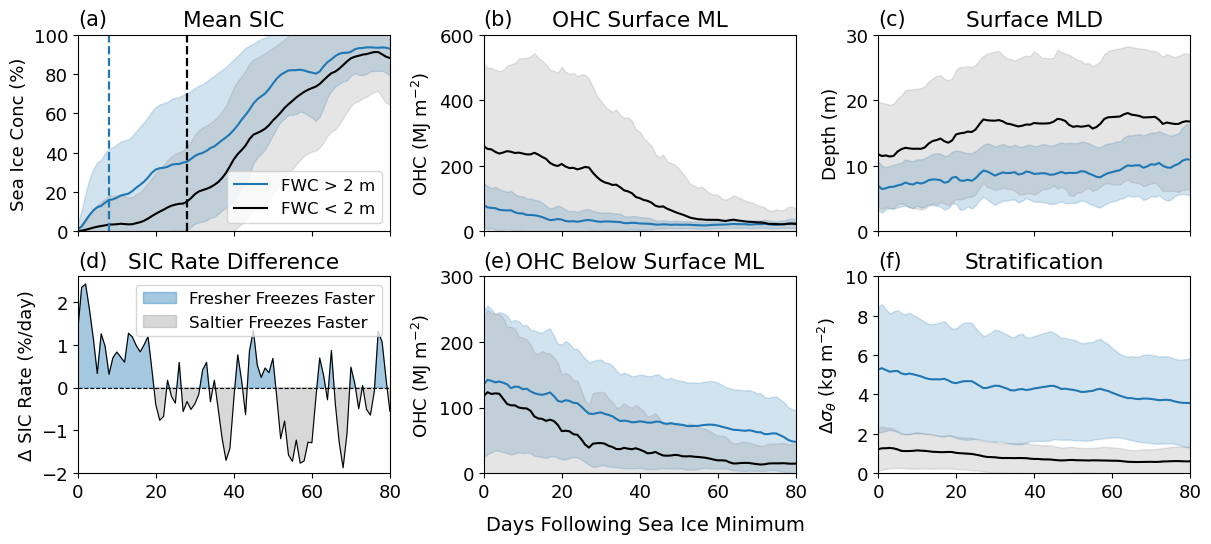

In [27]:
import string

plt.rcParams['font.size'] = 13

# Set up figure and axes
fig, axes = plt.subplots(2, 3, figsize=(12,5), sharex=True, constrained_layout=True)
axs = axes.flatten()

# Add subplot labels (a), (b), (c), ...
for i, ax in enumerate(axs):
    label = f"({string.ascii_lowercase[i]})"
    ax.text(0, 1.13, label, transform=ax.transAxes,
            fontsize=15, va='top', ha='left')

# plot SIC time series
plot_sic_mean(axs[0], sic_mean_under, sic_std_under, sic_mean_over, sic_std_over)

# plot OHC in surface ML time series
plot_var_mean(axs[1], ohc_mean_under, ohc_std_under, ohc_mean_over, ohc_std_over, upper_xy_limits=[80,600], \
              title='OHC Surface ML', ylabel='OHC (MJ m$^{-2}$)')

# plot MLD
plot_var_mean(axs[2], mld_mean_under, mld_std_under, mld_mean_over, mld_std_over, upper_xy_limits=[80,30], \
              title='Surface MLD', ylabel='Depth (m)')

# plot difference in SIC rate
plot_sic_diff_shading(axs[3], sic_mean_over, sic_mean_under)

# plot OHC in between surf and winter ML time series
plot_var_mean(axs[4], ohc_win_mean_under, ohc_win_std_under, ohc_win_mean_over, ohc_win_std_over, upper_xy_limits=[80,300], \
              title='OHC Below Surface ML', ylabel='OHC (MJ m$^{-2}$)')

# plot stratification
plot_var_mean(axs[5], strat_mean_under, strat_std_under, strat_mean_over, strat_std_over, upper_xy_limits=[80,10], \
              title='Stratification', ylabel='$\Delta \sigma_{\\theta}$ (kg m$^{-2}$)')

fig.text(0.4,-0.05,"Days Following Sea Ice Minimum",size=14)

fig.savefig('/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/fwc_group_mean_time_series_update.png', \
            dpi=300, bbox_inches='tight')

### Scatter plots to explore relationship between OHC, MLD, and Strat

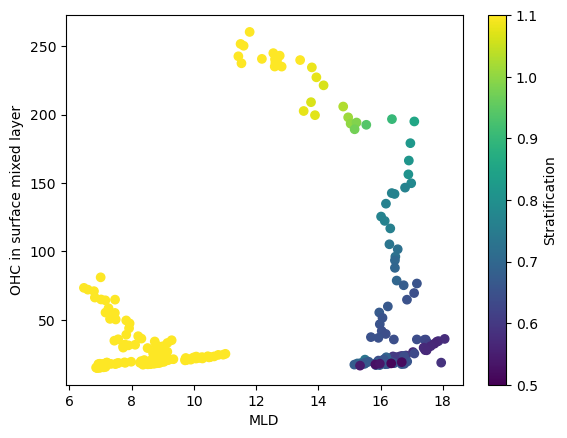

In [18]:
sc = plt.scatter(mld_mean_under, ohc_mean_under, c=strat_mean_under, vmin=0.5, vmax=1.1, cmap='viridis')
plt.scatter(mld_mean_over, ohc_mean_over, c=strat_mean_over, vmin=0.5, vmax=1.1, cmap='viridis')
plt.xlabel('MLD')
plt.ylabel('OHC in surface mixed layer')
cbar = plt.colorbar(sc)
cbar.set_label('Stratification')

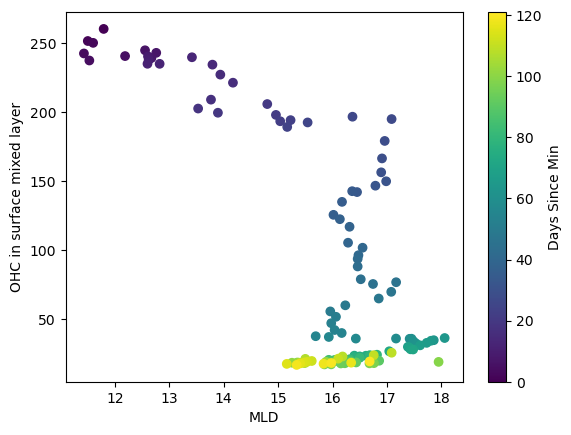

In [19]:
sc = plt.scatter(mld_mean_under, ohc_mean_under, c=strat_mean_under.days_since_min, cmap='viridis')
plt.xlabel('MLD')
plt.ylabel('OHC in surface mixed layer')
cbar = plt.colorbar(sc)
cbar.set_label('Days Since Min')

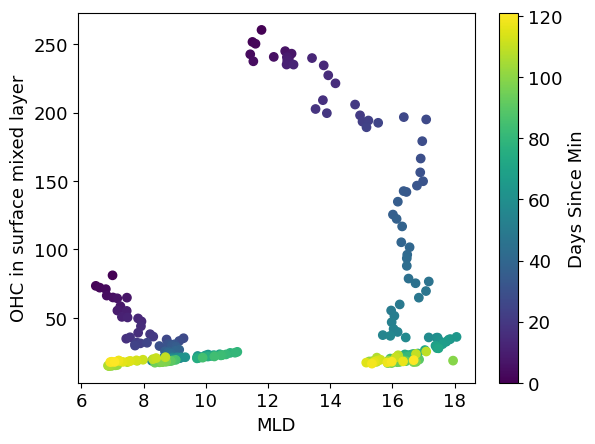

In [30]:
sc = plt.scatter(mld_mean_under, ohc_mean_under, c=strat_mean_under.days_since_min, cmap='viridis')
sc = plt.scatter(mld_mean_over, ohc_mean_over, c=strat_mean_over.days_since_min, cmap='viridis')
plt.xlabel('MLD')
plt.ylabel('OHC in surface mixed layer')
cbar = plt.colorbar(sc)
cbar.set_label('Days Since Min')

### Plot averages calculated for each year

In [15]:
variable_pairs = [
    (ice_fwc_over_2m, ice_fwc_under_2m),
    (ohc_fwc_over_2m, ohc_fwc_under_2m),
    (ohc_win_fwc_over_2m, ohc_win_fwc_under_2m),
    (mld_fwc_over_2m, mld_fwc_under_2m),
    (strat_fwc_over_2m, strat_fwc_under_2m)
]

In [16]:
ice_avg_over = ice_fwc_over_2m.mean(dim=['i','j'])
ice_avg_under = ice_fwc_under_2m.mean(dim=['i','j'])

mld_avg_over = mld_fwc_over_2m.mean(dim=['i','j'])
mld_avg_under = mld_fwc_under_2m.mean(dim=['i','j'])

ohc_avg_over = ohc_fwc_over_2m.mean(dim=['i','j'])
ohc_avg_under = ohc_fwc_under_2m.mean(dim=['i','j'])

strat_avg_over = strat_fwc_over_2m.mean(dim=['i','j'])
strat_avg_under = strat_fwc_under_2m.mean(dim=['i','j'])

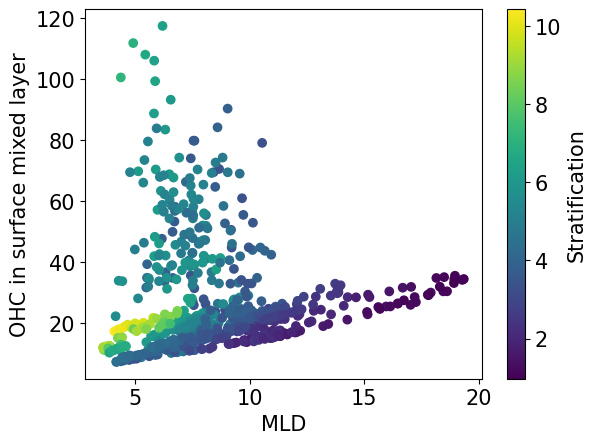

In [17]:
# sc = plt.scatter(mld_avg_under, ohc_avg_under, c=strat_avg_under, cmap='viridis')
sc = plt.scatter(mld_avg_over, ohc_avg_over, c=strat_avg_over, cmap='viridis')
plt.xlabel('MLD')
plt.ylabel('OHC in surface mixed layer')
cbar = plt.colorbar(sc)
cbar.set_label('Stratification')

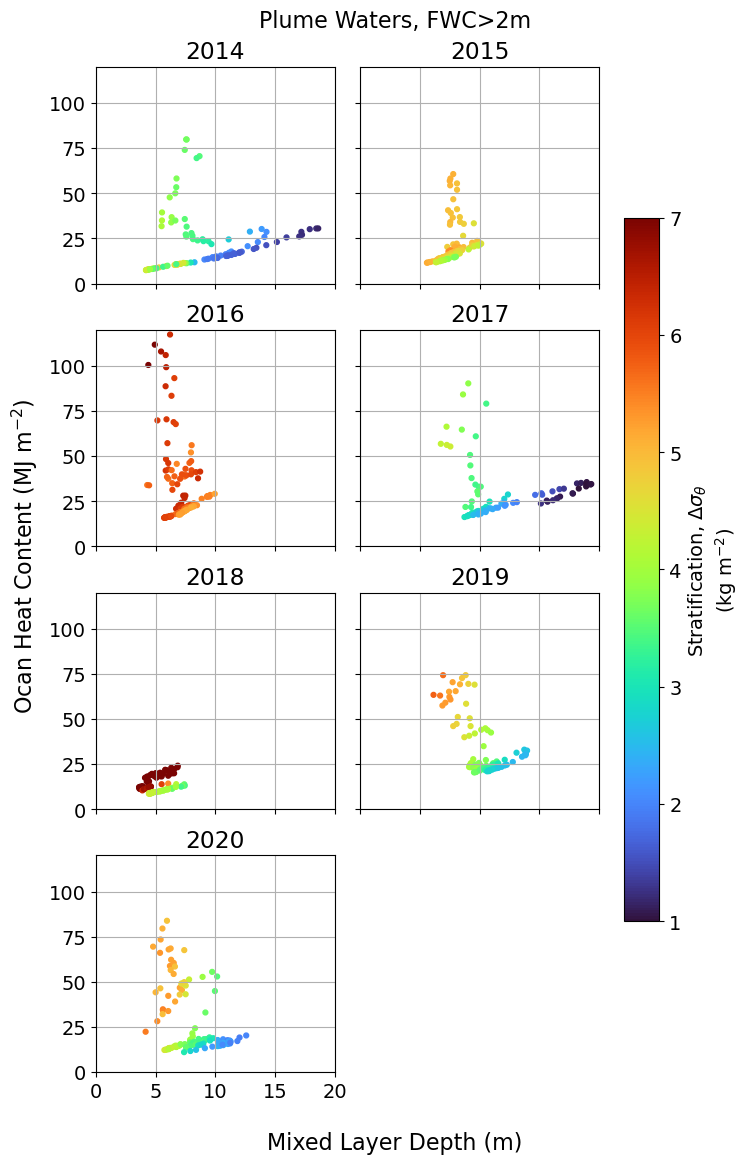

In [38]:
plt.rcParams['font.size'] = 14
years = range(2014, 2021)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(7, 11), sharey=True, sharex=True, constrained_layout=True)
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    
    # Select data for the current year
    mld_year = mld_avg_over.sel(time=str(year))
    ohc_year = ohc_avg_over.sel(time=str(year))
    strat_year = strat_avg_over.sel(time=str(year))

    # Flatten data and remove NaNs
    mask = np.isfinite(mld_year) & np.isfinite(ohc_year) & np.isfinite(strat_year)
    sc = ax.scatter(
        mld_year.values[mask],
        ohc_year.values[mask],
        c=strat_year.values[mask],
        cmap='turbo', vmin=1, vmax=7,
        s=12
    )
    
    ax.set_title(f'{year}')
    ax.grid()
    ax.set_ylim(0,120)
    ax.set_xlim(0,20)
    # ax.set_xlabel('MLD')
    # ax.set_ylabel('OHC')


# Remove the last subplot (empty)
if len(years) < len(axes):
    fig.delaxes(axes[-1])
    
# Add a shared colorbar
cbar = fig.colorbar(sc, ax=axes[:len(years)], orientation='vertical', shrink=0.7)
cbar.set_label('Stratification, $\Delta \\sigma_{\\theta}$\n(kg m$^{-2}$)')

# Add common x and y labels
fig.text(0.5, -0.04, 'Mixed Layer Depth (m)', ha='center', fontsize=16)
fig.text(-0.05, 0.5, 'Ocan Heat Content (MJ m$^{-2}$)', va='center', rotation='vertical', fontsize=16)

plt.suptitle('Plume Waters, FWC>2m', fontsize=16)
plt.show()

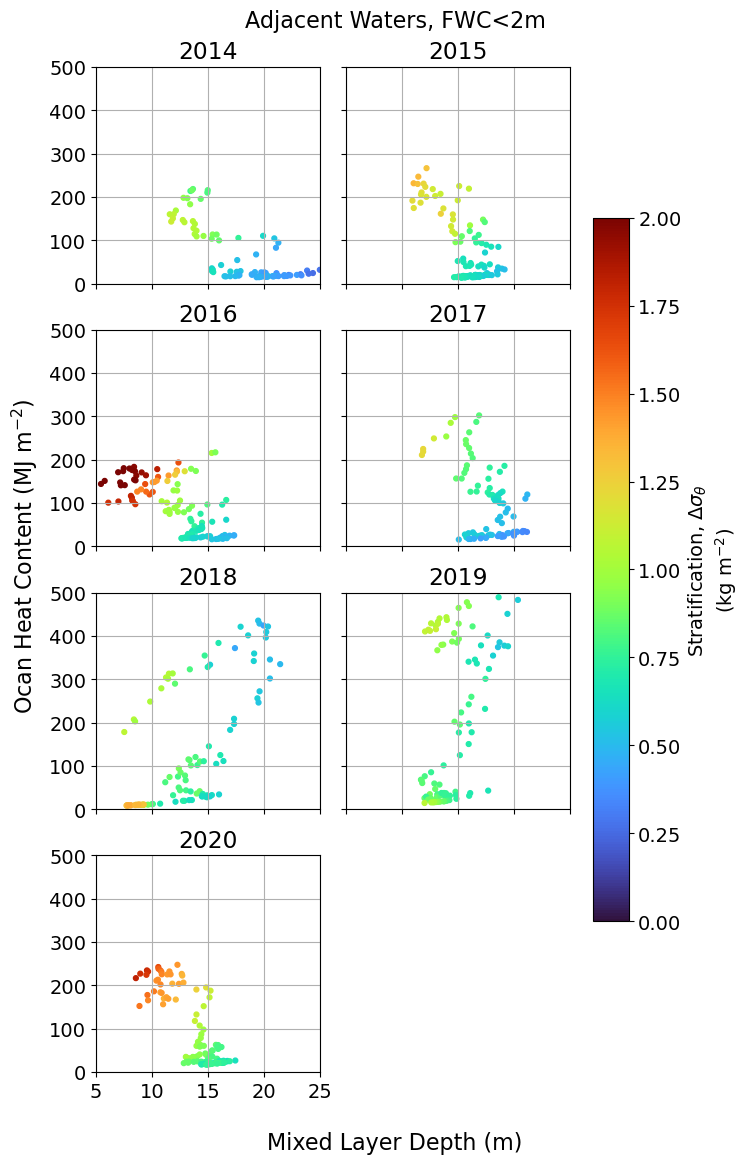

In [37]:
plt.rcParams['font.size'] = 14
years = range(2014, 2021)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(7, 11), sharey=True, sharex=True, constrained_layout=True)
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    
    # Select data for the current year
    mld_year = mld_avg_under.sel(time=str(year))
    ohc_year = ohc_avg_under.sel(time=str(year))
    strat_year = strat_avg_under.sel(time=str(year))

    # Flatten data and remove NaNs
    mask = np.isfinite(mld_year) & np.isfinite(ohc_year) & np.isfinite(strat_year)
    sc = ax.scatter(
        mld_year.values[mask],
        ohc_year.values[mask],
        c=strat_year.values[mask],
        cmap='turbo', vmin=0, vmax=2,
        s=12
    )
    
    ax.set_title(f'{year}')
    ax.grid()
    ax.set_ylim(0,500)
    ax.set_xlim(5,25)
    ax.set_xticks([5, 10, 15, 20, 25])
    # ax.set_xlabel('MLD')
    # ax.set_ylabel('OHC')


# Remove the last subplot (empty)
if len(years) < len(axes):
    fig.delaxes(axes[-1])
    
# Add a shared colorbar
cbar = fig.colorbar(sc, ax=axes[:len(years)], orientation='vertical', shrink=0.7)
cbar.set_label('Stratification, $\Delta \\sigma_{\\theta}$\n(kg m$^{-2}$)')

# Add common x and y labels
fig.text(0.5, -0.04, 'Mixed Layer Depth (m)', ha='center', fontsize=16)
fig.text(-0.05, 0.5, 'Ocan Heat Content (MJ m$^{-2}$)', va='center', rotation='vertical', fontsize=16)

plt.suptitle('Adjacent Waters, FWC<2m', fontsize=16)
plt.show()

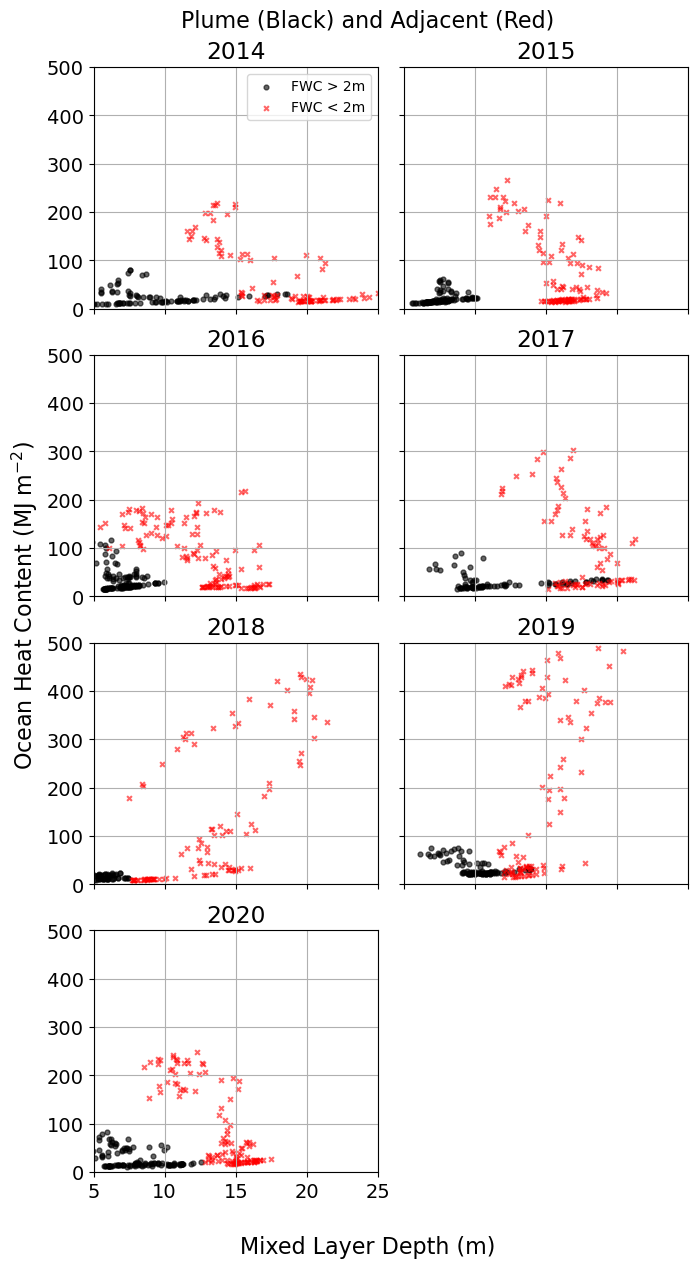

In [44]:
plt.rcParams['font.size'] = 14
years = range(2014, 2021)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(6.5, 12), sharex=True, sharey=True, constrained_layout=True)
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    
    # --- Over (Plume Waters, FWC > 2m) ---
    mld_over = mld_avg_over.sel(time=str(year))
    ohc_over = ohc_avg_over.sel(time=str(year))
    mask_over = np.isfinite(mld_over) & np.isfinite(ohc_over)
    ax.scatter(
        mld_over.values[mask_over],
        ohc_over.values[mask_over],
        color='black',
        s=12,
        label='FWC > 2m' if i == 0 else "",  # label only once for legend
        alpha=0.6
    )
    
    # --- Under (Adjacent Waters, FWC < 2m) ---
    mld_under = mld_avg_under.sel(time=str(year))
    ohc_under = ohc_avg_under.sel(time=str(year))
    mask_under = np.isfinite(mld_under) & np.isfinite(ohc_under)
    ax.scatter(
        mld_under.values[mask_under],
        ohc_under.values[mask_under],
        color='red',
        s=12,
        marker='x',
        label='FWC < 2m' if i == 0 else "",
        alpha=0.6
    )

    ax.set_title(f'{year}')
    ax.set_xlim(5, 25)
    ax.set_ylim(0, 500)
    ax.set_xticks([5, 10, 15, 20, 25])
    ax.grid(True)

# Remove unused subplot if needed
if len(years) < len(axes):
    fig.delaxes(axes[-1])

# Common axis labels
fig.text(0.5, -0.04, 'Mixed Layer Depth (m)', ha='center', fontsize=16)
fig.text(-0.05, 0.5, 'Ocean Heat Content (MJ m$^{-2}$)', va='center', rotation='vertical', fontsize=16)

# Suptitle
plt.suptitle('Plume (Black) and Adjacent (Red)', fontsize=16)

# Add legend to the first axis only
axes[0].legend(loc='upper right', fontsize=10)

plt.show()

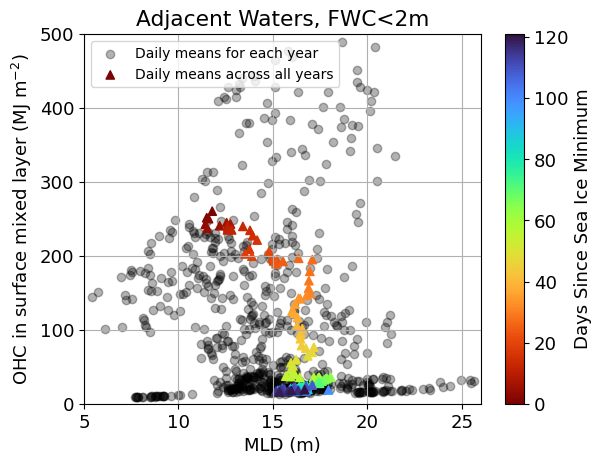

In [34]:
plt.scatter(mld_avg_under, ohc_avg_under, c='k',alpha=0.3,label='Daily means for each year')
sc = plt.scatter(mld_mean_under, ohc_mean_under, c=strat_mean_under.days_since_min, marker='^',cmap='turbo_r',label='Daily means across all years')

plt.xlim(5,26)
plt.ylim(0,500)

plt.legend(fontsize=10)
plt.grid()
plt.xlabel('MLD (m)')
plt.ylabel('OHC in surface mixed layer (MJ m$^{-2}$)')
cbar = plt.colorbar(sc)
cbar.set_label('Days Since Sea Ice Minimum')
plt.title('Adjacent Waters, FWC<2m');

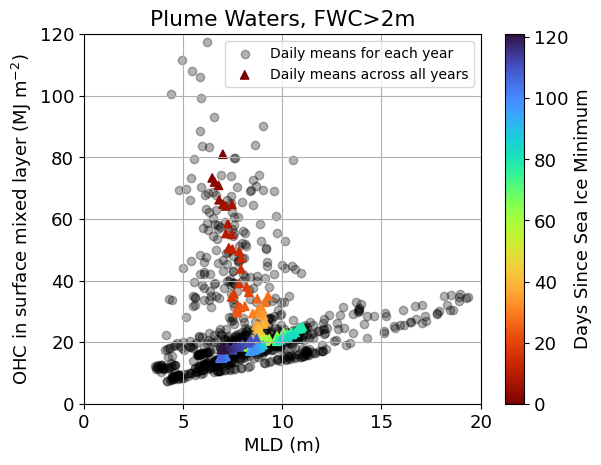

In [35]:
plt.scatter(mld_avg_over, ohc_avg_over, c='k',alpha=0.3,label='Daily means for each year')
sc = plt.scatter(mld_mean_over, ohc_mean_over, c=strat_mean_over.days_since_min, marker='^',cmap='turbo_r',label='Daily means across all years')

plt.xlim(0,20)
plt.ylim(0,120)

plt.legend(fontsize=10)
plt.grid()
plt.xlabel('MLD (m)')
plt.ylabel('OHC in surface mixed layer (MJ m$^{-2}$)')
cbar = plt.colorbar(sc)
cbar.set_label('Days Since Sea Ice Minimum')
plt.title('Plume Waters, FWC>2m');

/tmp/ipykernel_10313/1479220020.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(mld_mean_under, ohc_mean_under, c='magenta', marker='^',cmap='turbo_r',label='Daily means across all years')


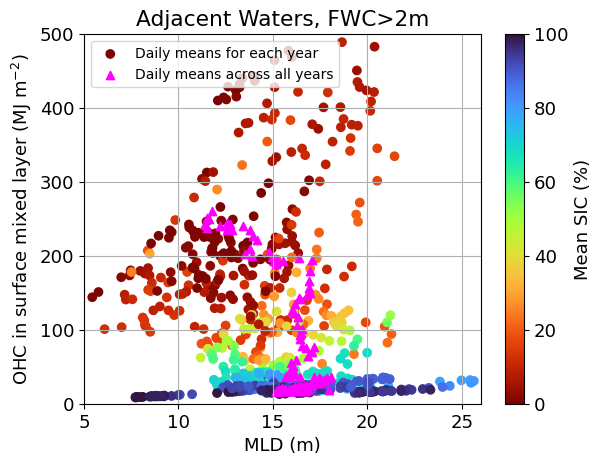

In [36]:
sc = plt.scatter(mld_avg_under, ohc_avg_under, c=ice_avg_under, vmin=0, vmax=100, cmap='turbo_r', label='Daily means for each year')
plt.scatter(mld_mean_under, ohc_mean_under, c='magenta', marker='^',cmap='turbo_r',label='Daily means across all years')

plt.xlim(5,26)
plt.ylim(0,500)

plt.legend(fontsize=10)
plt.grid()
plt.xlabel('MLD (m)')
plt.ylabel('OHC in surface mixed layer (MJ m$^{-2}$)')
cbar = plt.colorbar(sc)
cbar.set_label('Mean SIC (%)')
plt.title('Adjacent Waters, FWC>2m');

/tmp/ipykernel_10313/4125214121.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(mld_mean_over, ohc_mean_over, c='magenta', marker='^',cmap='turbo_r',label='Daily means across all years')


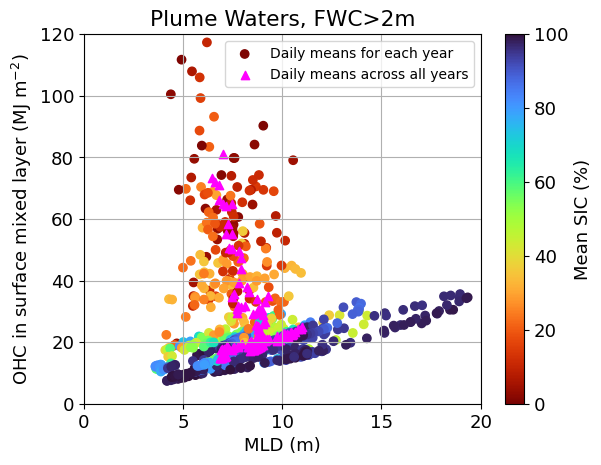

In [37]:
sc = plt.scatter(mld_avg_over, ohc_avg_over, c=ice_avg_over, vmin=0, vmax=100, cmap='turbo_r', label='Daily means for each year')
plt.scatter(mld_mean_over, ohc_mean_over, c='magenta', marker='^',cmap='turbo_r',label='Daily means across all years')

plt.xlim(0,20)
plt.ylim(0,120)

plt.legend(fontsize=10)
plt.grid()
plt.xlabel('MLD (m)')
plt.ylabel('OHC in surface mixed layer (MJ m$^{-2}$)')
cbar = plt.colorbar(sc)
cbar.set_label('Mean SIC (%)')
plt.title('Plume Waters, FWC>2m');